# ResNet18 Multi-Head Cloud Classifier

Branch a new 2-class head (cloud/clear_sky) from ResNet18's 512-dim penultimate layer, alongside the original frozen 1000-class ImageNet head. Only the new head is trained — the backbone and Head 1 are never modified.

In [25]:
from pathlib import Path
import os
import numpy as np
import cv2
from tqdm.auto import tqdm

IMAGES_PATH = Path("../resources/cloud-images/cloud-classifier-1")

def index_labeled_images(images_path=IMAGES_PATH):
    cloud_labels = []
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images, cloud_labels
    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        cloud_labels.append(cloud_dir.name)
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            labeled_images[img_path.name] = {"label": cloud_dir.name, "path": str(img_path)}
    return labeled_images, cloud_labels

def load_rgb_images(labeled_images, size=(224, 224)):
    images, labels = [], []
    for image_name in tqdm(labeled_images, total=len(labeled_images)):
        path = labeled_images[image_name]['path']
        if not os.path.exists(path):
            continue
        image = cv2.imread(path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, size)
        images.append(image)
        labels.append(labeled_images[image_name]['label'])
    return np.array(images), np.array(labels)

labeled_images, cloud_labels = index_labeled_images()
images, labels = load_rgb_images(labeled_images)
print(f"Loaded {len(images)} images — shape: {images.shape}, classes: {cloud_labels}")

100%|██████████| 698/698 [00:00<00:00, 1074.92it/s]

Loaded 698 images — shape: (698, 224, 224, 3), classes: ['clear_sky', 'cloud']


In [26]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

ordinal_encoder = LabelEncoder()
labels_encoded = ordinal_encoder.fit_transform(labels)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(images, labels_encoded))

X_train_imgs, X_test_imgs = images[train_idx], images[test_idx]
y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]

print("train:", X_train_imgs.shape, y_train.shape)
print("test: ", X_test_imgs.shape, y_test.shape)

train: (558, 224, 224, 3) (558,)
test:  (140, 224, 224, 3) (140,)


In [27]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SkyDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

BATCH_SIZE = 32

train_loader = DataLoader(SkyDataset(X_train_imgs, y_train, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(SkyDataset(X_test_imgs, y_test, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 18, Test batches: 5


In [28]:
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights

class MultiHeadResNet18(nn.Module):
    """
    ResNet18 with two classification heads branching from the 512-dim penultimate layer:
      Head 1 — original pretrained 1000-class ImageNet head (frozen)
      Head 2 — new 2-class head for cloud/clear_sky (trained from scratch)
    """
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # Backbone: everything up to (and including) avgpool
        self.backbone = nn.Sequential(*list(base.children())[:-1])

        # Head 1: original pretrained FC — frozen
        self.head1 = base.fc

        # Head 2: new FC for our task — trained from scratch
        self.head2 = nn.Linear(512, num_classes)

        # Freeze backbone and head1
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.head1.parameters():
            param.requires_grad = False

    def forward(self, x):
        features = self.backbone(x).flatten(1)  # (batch, 512)
        return self.head1(features), self.head2(features)

model = MultiHeadResNet18(num_classes=len(ordinal_encoder.classes_))

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Trainable params: 1,026 / 11,690,538 (0.0%)


In [29]:
import torch.optim as optim

EPOCHS   = 50
LR       = 1e-3
device   = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model     = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.head2.parameters(), lr=LR)

print(f"Training on: {device}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()
        _, out2 = model(imgs)          # only use head2 output for training
        loss = criterion(out2, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(targets)
        correct    += (out2.argmax(1) == targets).sum().item()
        n          += len(targets)

    print(f"Epoch {epoch:2d}/{EPOCHS}  loss: {total_loss/n:.4f}  train acc: {correct/n:.4f}")

Training on: mps
Epoch  1/50  loss: 0.5902  train acc: 0.6846
Epoch  2/50  loss: 0.2935  train acc: 0.9229
Epoch  3/50  loss: 0.2031  train acc: 0.9498
Epoch  4/50  loss: 0.1676  train acc: 0.9624
Epoch  5/50  loss: 0.1761  train acc: 0.9444
Epoch  6/50  loss: 0.1470  train acc: 0.9498
Epoch  7/50  loss: 0.1534  train acc: 0.9534
Epoch  8/50  loss: 0.1549  train acc: 0.9498
Epoch  9/50  loss: 0.1195  train acc: 0.9624
Epoch 10/50  loss: 0.1210  train acc: 0.9624
Epoch 11/50  loss: 0.1107  train acc: 0.9695
Epoch 12/50  loss: 0.1159  train acc: 0.9624
Epoch 13/50  loss: 0.0826  train acc: 0.9785
Epoch 14/50  loss: 0.1046  train acc: 0.9731
Epoch 15/50  loss: 0.1028  train acc: 0.9695
Epoch 16/50  loss: 0.0800  train acc: 0.9821
Epoch 17/50  loss: 0.0753  train acc: 0.9731
Epoch 18/50  loss: 0.1044  train acc: 0.9659
Epoch 19/50  loss: 0.0775  train acc: 0.9731
Epoch 20/50  loss: 0.1014  train acc: 0.9677
Epoch 21/50  loss: 0.1046  train acc: 0.9516
Epoch 22/50  loss: 0.0757  train acc: 

In [30]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = imgs.to(device)
        _, out2 = model(imgs)
        all_preds.extend(out2.argmax(1).cpu().numpy())
        all_targets.extend(targets.numpy())

print(f"Accuracy:  {accuracy_score(all_targets, all_preds):.4f}")
print(f"F1 macro:  {f1_score(all_targets, all_preds, average='macro'):.4f}")
print()
print(classification_report(all_targets, all_preds, target_names=ordinal_encoder.classes_))

Accuracy:  1.0000
F1 macro:  1.0000

              precision    recall  f1-score   support

   clear_sky       1.00      1.00      1.00        70
       cloud       1.00      1.00      1.00        70

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



In [33]:
from pathlib import Path

SAVE_PATH = Path("../models/multihead_resnet18_cloud_sky.pth")
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "classes":              [str(c) for c in ordinal_encoder.classes_],
    "num_classes":          len(ordinal_encoder.classes_),
}, SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")

Model saved to ../models/multihead_resnet18_cloud_sky.pth


## Sample Predictions: Head 1 (ImageNet) vs Head 2 (Cloud/Clear Sky)

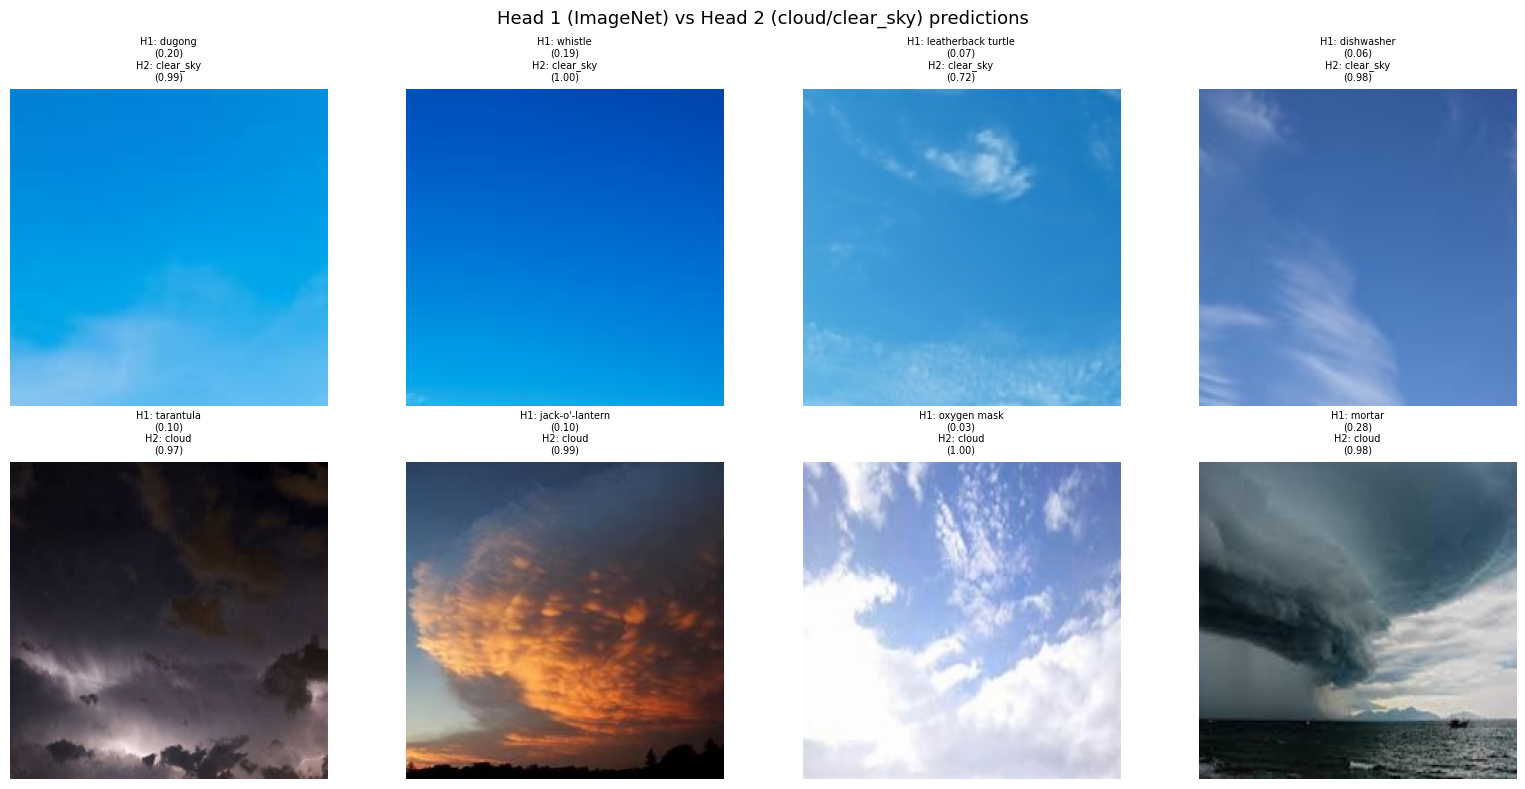

In [34]:
import matplotlib.pyplot as plt
from torch.nn.functional import softmax as F_softmax

imagenet_classes = ResNet18_Weights.IMAGENET1K_V1.meta["categories"]

N_SAMPLES = 4
categories = sorted(np.unique(labels[test_idx]))
fig, axes = plt.subplots(len(categories), N_SAMPLES, figsize=(16, 8))

model.eval()
val_tf = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

for row, category in enumerate(categories):
    cat_mask = labels[test_idx] == category
    cat_imgs = X_test_imgs[cat_mask]
    sample_idxs = np.random.RandomState(42).choice(len(cat_imgs), N_SAMPLES, replace=False)

    for col, idx in enumerate(sample_idxs):
        img = cat_imgs[idx]
        tensor = val_tf(img).unsqueeze(0).to(device)

        with torch.no_grad():
            out1, out2 = model(tensor)
            probs1 = F_softmax(out1, dim=1)[0]
            probs2 = F_softmax(out2, dim=1)[0]

        top1_imagenet = imagenet_classes[probs1.argmax().item()]
        top1_conf1    = probs1.max().item()
        pred_class    = ordinal_encoder.classes_[probs2.argmax().item()]
        pred_conf2    = probs2.max().item()

        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(
            f"H1: {top1_imagenet}\n({top1_conf1:.2f})\n"
            f"H2: {pred_class}\n({pred_conf2:.2f})",
            fontsize=7
        )

    axes[row, 0].set_ylabel(f"true: {category}", fontsize=10)

plt.suptitle("Head 1 (ImageNet) vs Head 2 (cloud/clear_sky) predictions", fontsize=13)
plt.tight_layout()
plt.show()